In [1]:
# imports

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.ensemble import HistGradientBoostingRegressor, ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge, ElasticNet

In [2]:
df = pd.read_csv("../data/cleaned-engineered.csv")
df.head()

,List Year,Date Recorded,Town,Assessed Value,Sale Amount,Property Type,Residential Type,Location,Sale Year,Sale Month,...,Longitude,Dist To NYC,Dist To Hartford,Dist To Boston,Approx Dist To Coast,Town Median Sale Amount,Town Avg Assessment Ratio,Town Avg Sale Amount,Town Market Strength,Luxury Home
0,2010,2010-10-02,Norwalk,339640.0,265000.0,Residential,Single Family,POINT (-73.408 41.118),2010,10,...,-73.408,41.936910,58.745280,148.427562,8.142,420000.0,1.876569,617242.675586,1.650295,0
1,2010,2010-10-03,Milford,674350.0,788000.0,Residential,Single Family,POINT (-73.057 41.222),2010,10,...,-73.057,60.737843,42.495549,129.526272,15.318,287000.0,1.496553,344579.129171,1.127701,0
2,2010,2010-10-04,Bridgeport,132250.0,148000.0,Residential,Single Family,POINT (-73.195 41.186),2010,10,...,-73.195,53.480470,48.310972,136.729259,12.834,160000.0,1.492121,212777.367623,0.628684,0
3,2010,2010-10-04,Bristol,99610.0,32000.0,Residential,Single Family,POINT (-72.94 41.671),2010,10,...,-72.940,86.341970,15.229990,107.661631,46.299,185000.0,1.731108,211111.211163,0.726916,0
4,2010,2010-10-04,Bridgeport,132260.0,110000.0,Residential,Single Family,POINT (-73.195 41.186),2010,10,...,-73.195,53.480470,48.310972,136.729259,12.834,160000.0,1.492121,212777.367623,0.628684,0


In [3]:
print(df.shape)
print(df.columns)

(614534, 26)
Index(['List Year', 'Date Recorded', 'Town', 'Assessed Value', 'Sale Amount',
       'Property Type', 'Residential Type', 'Location', 'Sale Year',
       'Sale Month', 'Sale Quarter', 'Sale Day Of Year', 'Assessment Ratio',
       'Assessment Gap', 'Log Assessed Value', 'Latitude', 'Longitude',
       'Dist To NYC', 'Dist To Hartford', 'Dist To Boston',
       'Approx Dist To Coast', 'Town Median Sale Amount',
       'Town Avg Assessment Ratio', 'Town Avg Sale Amount',
       'Town Market Strength', 'Luxury Home'],
      dtype='str')


In [4]:
'''
the following features are dropped from the evaluated data because they are engineered using sale price.
there is a check at the bottom to include properties only within a reasonable price range.
'''

drop_cols = [
    "Assessment Ratio",
    "Assessment Gap",
    "Town Avg Sale Amount",
    "Town Median Sale Amount",
    "Luxury Home"   # uses Sale Amount
]

df = df.drop(columns=[col for col in drop_cols if col in df.columns])
df = df.drop(columns=["Date Recorded", "Location"], errors="ignore")
df = df[df["Sale Amount"].between(10_000, 5_000_000)] # outlier trimming

In [5]:
X = df.drop(columns=["Sale Amount"])
y = df["Sale Amount"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [7]:
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

In [8]:
categorical_cols = ["Town", "Property Type", "Residential Type"]
numerical_cols = [col for col in X.columns if col not in categorical_cols]

print("Categorical:", categorical_cols)
print("Numeric:", numerical_cols[:10], "... total =", len(numerical_cols))

Categorical: ['Town', 'Property Type', 'Residential Type']
Numeric: ['List Year', 'Assessed Value', 'Sale Year', 'Sale Month', 'Sale Quarter', 'Sale Day Of Year', 'Log Assessed Value', 'Latitude', 'Longitude', 'Dist To NYC'] ... total = 15


**Below are the preprocessing pipelines for all the models used in this notebook as well as a helper function to aid output**

In [9]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numerical_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols)
    ]
)

In [10]:
linear_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numerical_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), categorical_cols)
    ]
)

In [11]:
hgb_preprocessor = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numerical_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), categorical_cols)
    ]
)

In [12]:
def evaluate_model(name, pipeline, X_train, y_train_log, X_test, y_test):
    pipeline.fit(X_train, y_train_log)

    # Predict in log space, then transform back
    y_pred_log = pipeline.predict(X_test)
    y_pred = np.expm1(y_pred_log)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    print(f"{name}")
    print(f"MSE:  {mse}")
    print(f"RMSE: {rmse}")
    print(f"R^2:  {r2}")
    print()

    return {
        "Model": name,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "pipeline": pipeline,
        "predictions": y_pred
    }

**Pipelines for each model contained in this notebook:**
1) HistGradientBoostingRegressor - advanced boosting model designed for large tabular datasets
2) RandomForestRegressor - reliable nonlinear model that handles interactions, nonlinearity, and mixed feature types
3) ExtraTreesRegressor - similar to random forest, but splits are chosen randomly instead of finding best split
4) Ridge Regression - Additional method for baseline modeling
5) ElasticNet - Additional method for baseline modeling and feature contextualization

In [13]:
hgb_pipeline = Pipeline([
    ("preprocessor", hgb_preprocessor),
    ("model", HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.05,
        max_depth=8,
        min_samples_leaf=20,
        l2_regularization=1.0,
        random_state=42
    ))
])

In [14]:
rf_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=150,
        max_depth=20,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42
    ))
])

In [15]:
et_pipeline = Pipeline([
    ("preprocessor", tree_preprocessor),
    ("model", ExtraTreesRegressor(
        n_estimators=200,
        max_depth=25,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42
    ))
])

In [16]:
ridge_pipeline = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model", Ridge(alpha=10.0))
])

In [17]:
enet_pipeline = Pipeline([
    ("preprocessor", linear_preprocessor),
    ("model", ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=5000, random_state=42))
])

In [18]:
'''
calls helper function on each pipeline and outputs their results.
this cell took me an hour to run, so be mindful of that when looking over this notebook.
'''

results = []

results.append(evaluate_model(
    "HistGradientBoosting", hgb_pipeline, X_train, y_train_log, X_test, y_test
))

results.append(evaluate_model(
    "ExtraTrees", et_pipeline, X_train, y_train_log, X_test, y_test
))

results.append(evaluate_model(
    "RandomForest", rf_pipeline, X_train, y_train_log, X_test, y_test
))

results.append(evaluate_model(
    "Ridge", ridge_pipeline, X_train, y_train_log, X_test, y_test
))

results.append(evaluate_model(
    "ElasticNet", enet_pipeline, X_train, y_train_log, X_test, y_test
))

HistGradientBoosting
MSE:  38220125377.45354
RMSE: 195499.68127199987
R^2:  0.8058911517456084

ExtraTrees
MSE:  32081357551.568256
RMSE: 179112.6951155843
R^2:  0.8370681596862113

RandomForest
MSE:  32739311399.078476
RMSE: 180940.07681848286
R^2:  0.8337266043594438

Ridge
MSE:  84875491385.859
RMSE: 291333.9859780506
R^2:  0.5689421812401103

ElasticNet
MSE:  82844186982.59122
RMSE: 287826.661347748
R^2:  0.5792585827243656



In [19]:
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ["pipeline", "predictions"]}
    for r in results
]).sort_values(by="R2", ascending=False)

results_df # result ranking based on R^2 value

,Model,MSE,RMSE,R2
1,ExtraTrees,3.208136e+10,179112.695116,0.837068
2,RandomForest,3.273931e+10,180940.076818,0.833727
0,HistGradientBoosting,3.822013e+10,195499.681272,0.805891
4,ElasticNet,8.284419e+10,287826.661348,0.579259
3,Ridge,8.487549e+10,291333.985978,0.568942


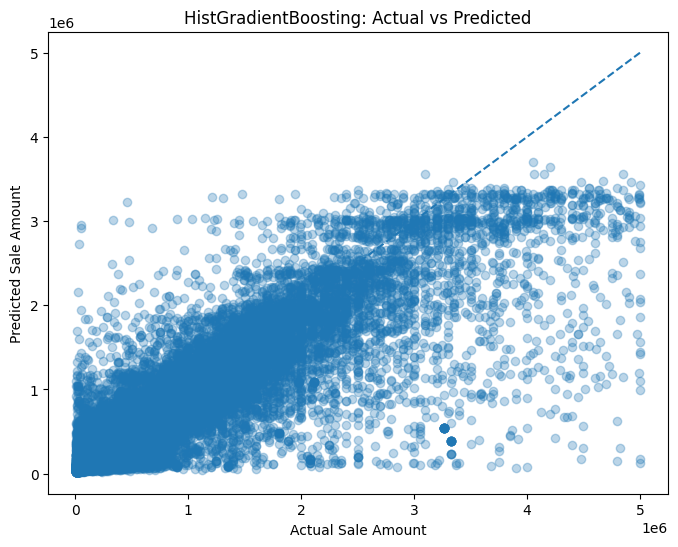

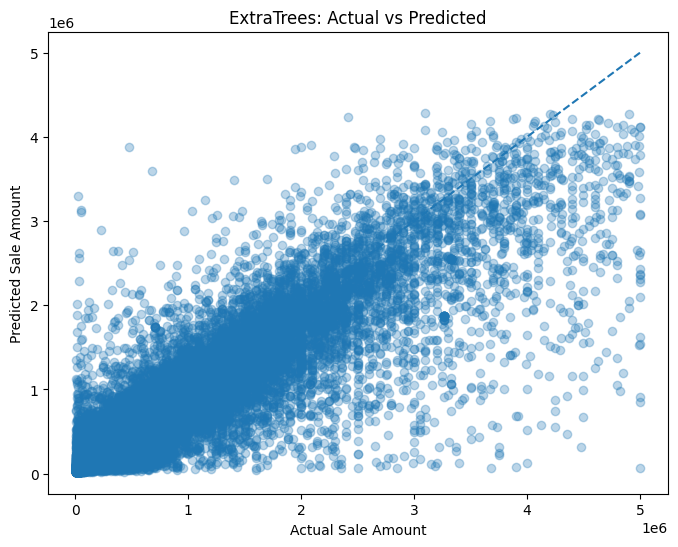

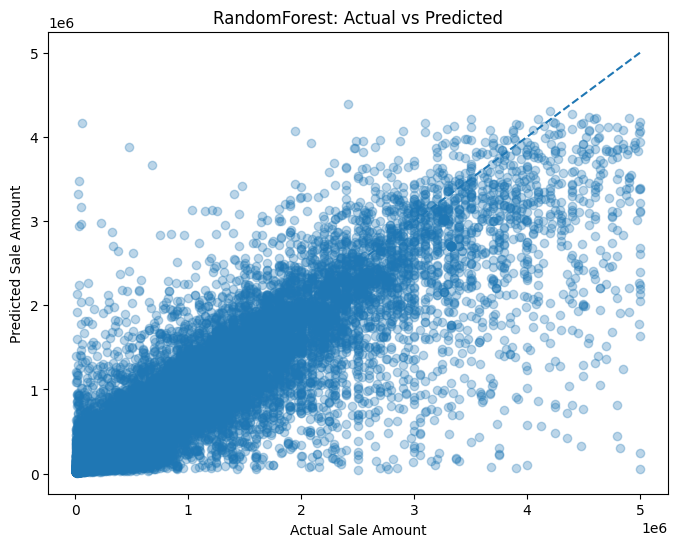

In [20]:
import matplotlib.pyplot as plt

non_baseline_models = {"ExtraTrees", "RandomForest", "HistGradientBoosting"}

for r in results:
    if r["Model"] in non_baseline_models:
        y_pred = r["predictions"]

        plt.figure(figsize=(8, 6))
        plt.scatter(y_test, y_pred, alpha=0.3)
        plt.plot(
            [y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            linestyle="--"
        )
        plt.xlabel("Actual Sale Amount")
        plt.ylabel("Predicted Sale Amount")
        plt.title(f'{r["Model"]}: Actual vs Predicted')
        plt.show()